## Visualize results

In [ ]:
# import Pkg
# Pkg.activate("..")
# Pkg.instantiate()

  Activating project at `/home/synd/Wouter/Onderzoek/Projecten/tue/tgp-hopt-ar/hopt-bar`


In [1]:
using Revise
using Distributions
using LinearAlgebra
using JLD2
using Plots;
using TuePlots; 
theme(:default;
    TuePlots.get_plotsjl_theme_kwargs(
        TuePlots.SETTINGS[:ProbNum25];
        fontsize = true,
        figsize = true,
    )...)


In [3]:
# Number of repetitions
num_reps = 50

# Time settings
Δt = 0.1
len_times = 2 .^collect(2:10)
num_times = length(len_times)

# Preallocate result arrays
runtimes_GP = zeros(num_times, num_reps)
runtimes_AR = zeros(num_times, num_reps)

# Collect results
for (nn,len_time) in enumerate(len_times)
    lt = lpad(len_time, 5, '0')

    res = load("results/runtimes-AR1-lentime$lt.jld2")
    runtimes_GP[nn,:] = res["runtimes_GP"]
    runtimes_AR[nn,:] = res["runtimes_AR"]
       
end

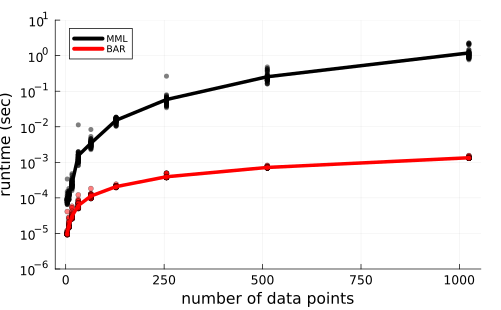

In [4]:
# with_theme(T) do
#     fig = Figure()
#     ax = Axis(fig[1, 1], xlabel = "number of data points", ylabel = "runtime (msec)")

#     sp = series!(ax, len_times, mean(times,dims=2)', ribbon=std(times,dims=2)')
#     # axislegend(ax)
#     # CairoMakie.ylims!(ax,-3,3)
#     hidespines!(ax, :t, :r)
#     save("figures/GPMat12_runtimes.pdf", fig, pt_per_unit = 1) # pt_per_unit is needed to ensure the correct sizes
# end

plot(xlabel="number of data points", ylabel="runtime (sec)", yscale=:log10, legend=:topleft)
# plot!(len_times, mean(times,dims=2), ribbon=std(times,dims=2)')
for (k,len_time) in enumerate(len_times)
    scatter!(len_time*ones(num_reps), runtimes_GP[k,:], color="black", alpha=0.5, label="")
    scatter!(len_time*ones(num_reps), runtimes_AR[k,:], color="red", alpha=0.5, label="")
end
plot!(len_times, mean(runtimes_GP,dims=2), linewidth=5, color="black", alpha=1., label="MML", ylims=(0,1.), margin=15Plots.pt)
plot!(len_times, mean(runtimes_AR,dims=2), linewidth=5, color="red", alpha=1., label="BAR", ylims=(0,1.), margin=15Plots.pt)
plot!(ylims=(1e-6,1e1), guidefontsize=15, tickfontsize=12)

In [ ]:
savefig("figures/runtimes-GP-vs-AR.pdf")

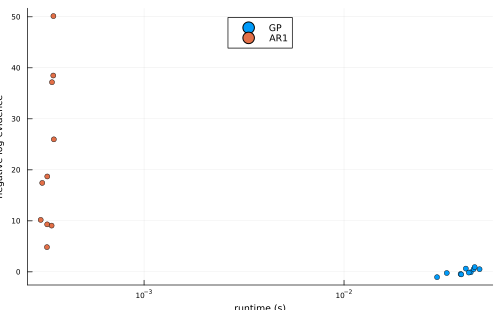

In [8]:
plot(xlabel="runtime (s)", ylabel="negative log-evidence", xscale=:log10, legend=:top)
scatter!(times_GP,  NLE_GP,  label="GP")
# scatter!(times_TGP, NLE_TGP, label="TGP")
scatter!(times_AR1, NLE_AR1, label="AR1")

In [1]:
plot(xlabel="runtime (ms)", ylabel="mean marginal likelihood", xscale=:log10)
scatter!(times_GP.*1000,  MML_GP,  label="GP")
# scatter!(times_TGP.*1000, MML_TGP, label="TGP")
scatter!(times_AR1.*1000, MML_AR1, label="AR1")
# plot!(xlims=[1e-1,3], xticks=[1e-1,1e0])
# plot!(ylims=[1e-4,1e-2], xticks=[1e-4,1e-3,1e-2])

UndefVarError: UndefVarError: `plot` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [42]:
savefig("figures/experiment-AR1-MLL.png")

"c:\\Syndr\\Wouter\\Onderzoek\\Projecten\\tue\\tgp-hopt-ar\\hopt-bar\\mc-experiments\\figures\\experiment-AR1-MLL.png"